<a href="https://www.kaggle.com/code/sonawanelalitsunil/grocery-store-sales-dataset-2025-ml-10?scriptVersionId=254829281" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/grocery-store-sales-dataset-in-2025-1900-record/grocery_chain_data.csv
/kaggle/input/grocery-store-sales-dataset-in-2025-1900-record/grocery_chain_data.json
/kaggle/input/grocery-store-sales-dataset-in-2025-1900-record/grocery_chain_data.xlsx


## Title:
Grocery Store Sales Dataset (2025) – 1900+ Transactions

## Description:
This dataset contains over 1900 transaction records from a grocery store collected during the year 2025. Each record captures detailed sales information including:

Order ID and Date of transaction

Product Name, Category, and Price

Quantity Sold and Total Sales (INR)

Payment Method (e.g., Cash, Card, UPI)

Customer Rating for service or product

This dataset can be used for various data analysis and machine learning tasks such as:

Sales forecasting

Customer behavior analysis

Product performance tracking

Market basket analysis

Payment method trends

Ideal for building dashboards, training models, or developing insights into retail and consumer patterns in the grocery sector.

## import dataset

In [2]:
df= pd.read_csv("/kaggle/input/grocery-store-sales-dataset-in-2025-1900-record/grocery_chain_data.csv")

In [3]:
df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2.0,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1.0,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4.0,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3.0,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5.0,8.66,43.30,1.50,41.80,22


In [4]:
df.tail()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
1975,1699,Corner Grocery,2024-07-30,Frozen Foods,Salmon,3.0,9.79,29.37,4.41,24.96,274
1976,1829,City Fresh Store,2023-12-15,Personal Care,Potatoes,4.0,22.96,91.84,9.18,82.66,429
1977,8096,MegaMart Westside,2025-05-06,Dairy,Potatoes,3.0,16.44,49.32,7.40,41.92,315
1978,7471,QuickStop Market,2024-08-26,Frozen Foods,Rice,5.0,15.88,79.40,15.88,63.52,160
1979,1483,FamilyFood Express,2024-05-30,Canned Goods,Rice,2.0,24.94,49.88,7.48,42.40,265


In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

customer_id          0
store_name          25
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64

In [7]:
df.shape

(1980, 11)

In [8]:
df.dtypes

customer_id           int64
store_name           object
transaction_date     object
aisle                object
product_name         object
quantity            float64
unit_price          float64
total_amount        float64
discount_amount     float64
final_amount        float64
loyalty_points        int64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   float64
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 170.3+ KB


In [10]:
df.columns

Index(['customer_id', 'store_name', 'transaction_date', 'aisle',
       'product_name', 'quantity', 'unit_price', 'total_amount',
       'discount_amount', 'final_amount', 'loyalty_points'],
      dtype='object')

## Data visualizations

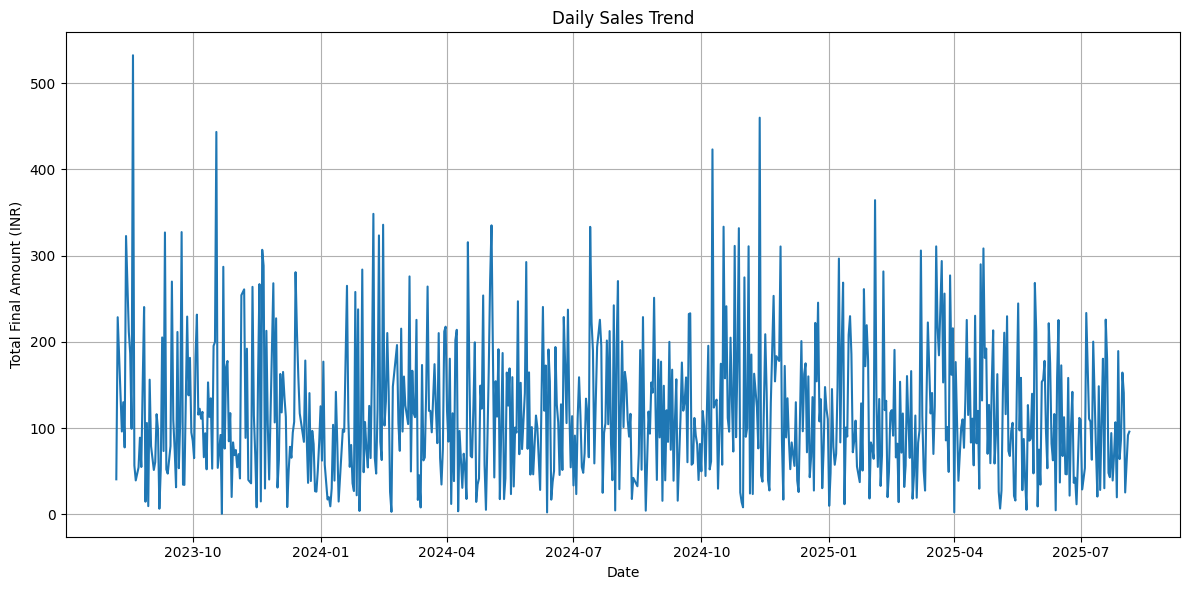

In [11]:

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df_daily = df.groupby(df['transaction_date'].dt.date)['final_amount'].sum()

plt.figure(figsize=(12,6))
df_daily.plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Final Amount (INR)')
plt.grid(True)
plt.tight_layout()
plt.show()

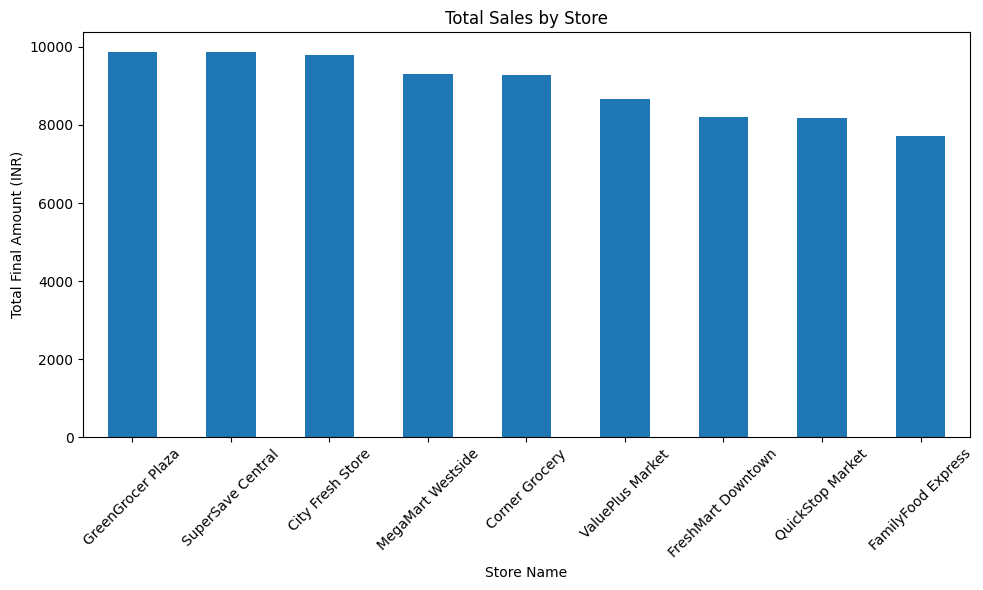

In [12]:
store_sales = df.groupby('store_name')['final_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
store_sales.plot(kind='bar')
plt.title('Total Sales by Store')
plt.xlabel('Store Name')
plt.ylabel('Total Final Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


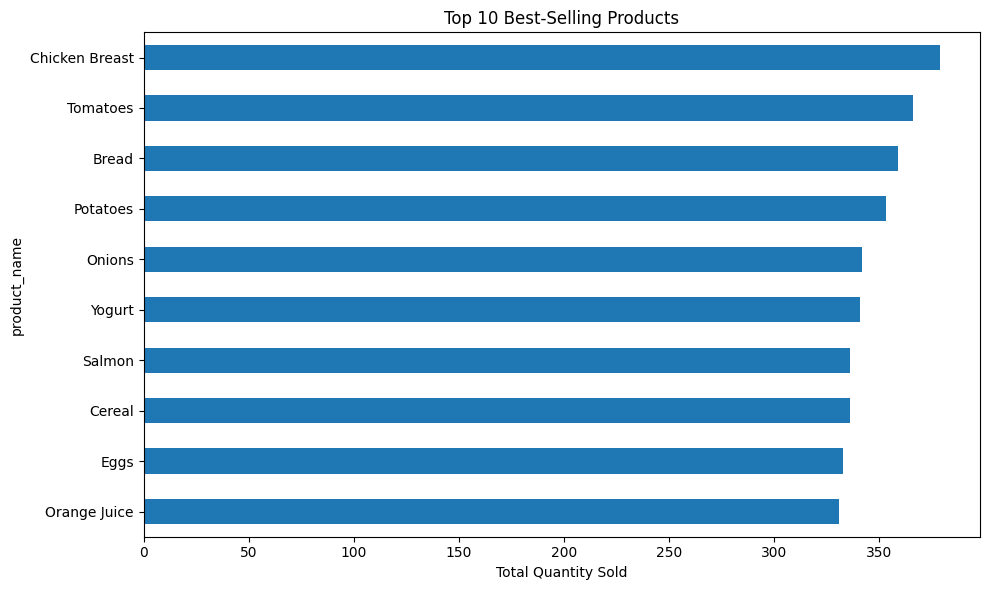

In [13]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()


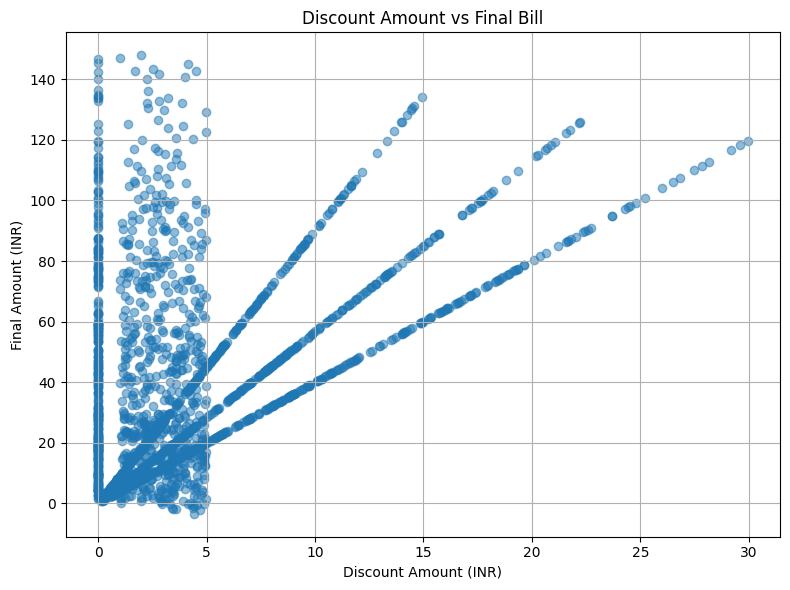

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(df['discount_amount'], df['final_amount'], alpha=0.5)
plt.title('Discount Amount vs Final Bill')
plt.xlabel('Discount Amount (INR)')
plt.ylabel('Final Amount (INR)')
plt.grid(True)
plt.tight_layout()
plt.show()


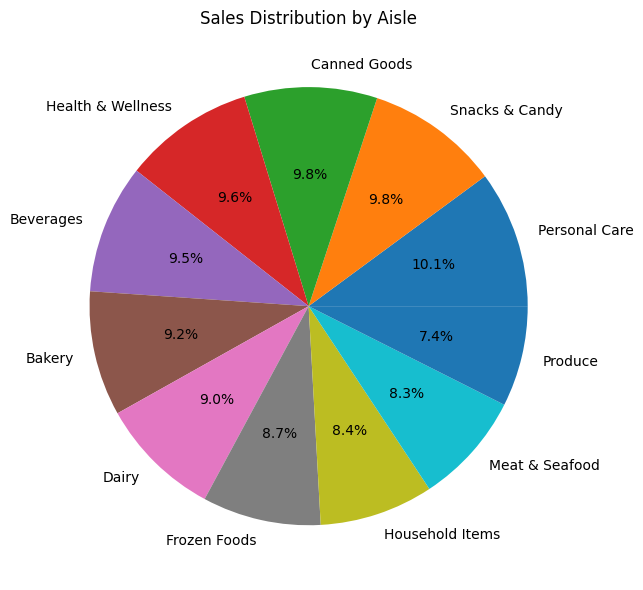

In [15]:
aisle_sales = df.groupby('aisle')['final_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
aisle_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Aisle')
plt.ylabel('')
plt.tight_layout()
plt.show()


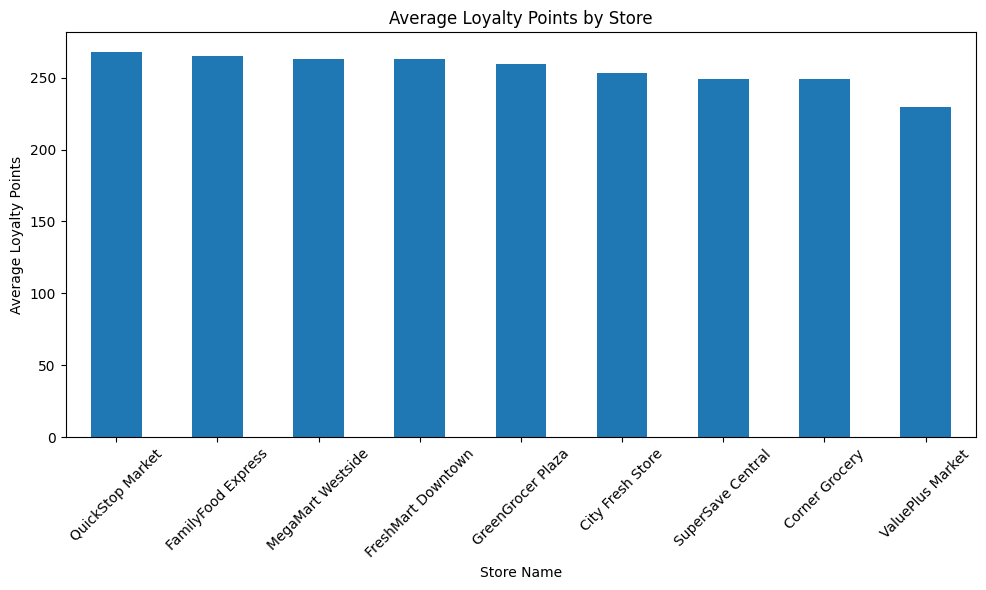

In [16]:
avg_loyalty = df.groupby('store_name')['loyalty_points'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_loyalty.plot(kind='bar')
plt.title('Average Loyalty Points by Store')
plt.xlabel('Store Name')
plt.ylabel('Average Loyalty Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [18]:
# Drop rows with missing values (if any)
df.dropna(inplace=True)

# Convert transaction_date to datetime and extract features
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['day'] = df['transaction_date'].dt.day
df['month'] = df['transaction_date'].dt.month
df['year'] = df['transaction_date'].dt.year
df['weekday'] = df['transaction_date'].dt.weekday

# Drop original date
df.drop('transaction_date', axis=1, inplace=True)

# Label encode categorical columns
le = LabelEncoder()
df['customer_id'] = le.fit_transform(df['customer_id'])
df['aisle'] = le.fit_transform(df['aisle'])
df['product_name'] = le.fit_transform(df['product_name'])
df['store_name'] = le.fit_transform(df['store_name'])  # Target
target_names = le.classes_

# Define X and y
X = df.drop('store_name', axis=1)
y = df['store_name']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    accuracies[name] = acc

# Print accuracies
print("Model Accuracies (%):")
for model, acc in accuracies.items():
    print(f"{model}: {acc:.2f}%")

Model Accuracies (%):
Logistic Regression: 10.23%
Decision Tree: 11.25%
Random Forest: 10.23%
Naive Bayes: 8.44%
Support Vector Machine: 8.70%
K-Nearest Neighbors: 7.93%


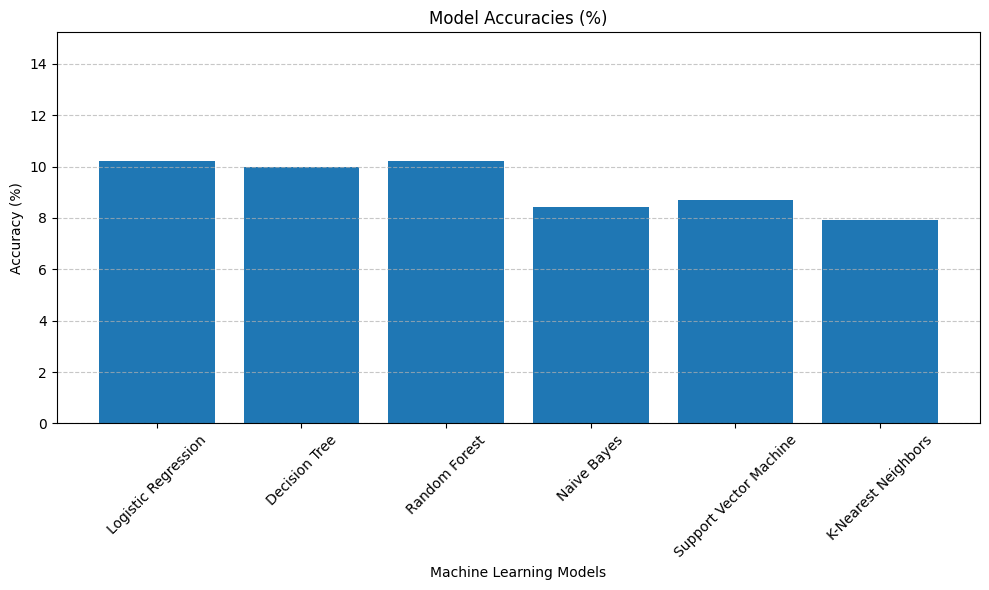

In [20]:
# Model accuracies (in %)
accuracies = {
    "Logistic Regression": 10.23,
    "Decision Tree": 9.97,
    "Random Forest": 10.23,
    "Naive Bayes": 8.44,
    "Support Vector Machine": 8.70,
    "K-Nearest Neighbors": 7.93
}

# Plot
plt.figure(figsize=(10,6))
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracies (%)")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0, max(accuracies.values()) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Thank you ...pls upvote!!!